In [17]:
from droste import droste, search_magenta
import io
import cairosvg
from skimage.transform import warp_polar, rotate, rescale
from skimage.util import img_as_float

from PIL import Image

import matplotlib.pyplot as plt
import numpy as np
import cv2

In [18]:
#image = cairosvg.svg2png(url = "../matte_framed_magenta.svg")
#image = Image.open(io.BytesIO(image))

image = Image.open("../frame_magenta.png")

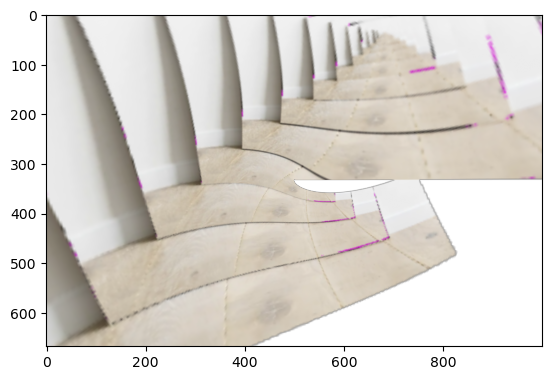

In [19]:
def find_center_offset(image):
    if image.mode == "RGBA":
        magenta = (255, 0, 255, 255)
    elif image.mode == "RGB":
        magenta = (255, 0, 255)

    left, right, top, bottom = search_magenta(image, magenta)
    arr_image = img_as_float(image)

    h, w = arr_image.shape[:2]

    center = (h // 2, w // 2)

    magenta_center = ((top+bottom) // 2, (left + right) //2)

    dx = center[1] - magenta_center[1]
    dy = center[0] - magenta_center[0]

    arr_image = np.roll(arr_image, (dy, dx), axis = (0, 1))

    return image

def escher_print(image, rot = 20, translate = (50, 20)):
    arr_image = img_as_float(image)

    h, w = arr_image.shape[:2]
    center = (w // 2, h // 2)

    M = h / np.log(h)

    arr_image = cv2.logPolar(
        arr_image,
        center = center,
        M = M,
        flags = cv2.INTER_LINEAR + cv2.WARP_FILL_OUTLIERS
    )

    mat = cv2.getRotationMatrix2D(center, rot, 1.0)

    # add shift to the affine matrix
    mat[0, 2] += translate[0]
    mat[1, 2] += translate[1]


    arr_image= cv2.warpAffine(arr_image, mat, (w, h))


    arr_image = cv2.logPolar(
        arr_image,
        center = center,
        M = M,
        flags = cv2.INTER_LINEAR + cv2.WARP_INVERSE_MAP
    )

    return arr_image

t_image = find_center_offset(image)
t_image = droste(t_image)
t_image = escher_print(t_image)
plt.imshow(t_image)
plt.show()